# **Breast Cancer Detection**

# Breast Cancer Detection – Exploratory Data Analysis (EDA)

## 1. Project Objective

The main objective of this project is to analyze the Breast Cancer dataset and build a predictive system that can determine whether a patient is **Alive** or **Dead** based on medical and clinical features.

---

## 2. Dataset Information

- **Dataset Name:** Breast_Cancer.csv
- **Dataset Type:** Medical Dataset
- **Problem Type:** Classification
- **Target Column:** Status
- **Target Classes:** Alive, Dead

The dataset contains patient medical information related to breast cancer and survival analysis.

---

## 3. Features Description

| Column Name | Description |
|---|---|
| Age | Age of the patient |
| Race | Race category of patient |
| Marital Status | Marital status of patient |
| T Stage | Tumor stage |
| N Stage | Lymph node stage |
| 6th Stage | Cancer stage |
| differentiate | Cancer differentiation level |
| Grade | Cancer grade |
| A Stage | Cancer stage category |
| Tumor Size | Size of tumor |
| Estrogen Status | Estrogen hormone status |
| Progesterone Status | Progesterone hormone status |
| Regional Node Examined | Number of nodes examined |
| Reginol Node Positive | Number of positive regional nodes |
| Survival Months | Survival duration of patient |
| Status | Patient survival status (Alive/Dead) |


# 📦Importing Required Libraries

Before starting Exploratory Data Analysis (EDA), we need to import some important Python libraries. These libraries help in data handling, numerical operations, and data visualization.

| Library | Purpose |
|---|---|
| Pandas | Used for data manipulation and analysis |
| NumPy | Used for numerical and mathematical operations |
| Matplotlib | Used for creating graphs and visualizations |
| Seaborn | Used for advanced statistical data visualization |


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### **1. Load Dataset**

In [37]:
df = pd.read_csv("data/Breast_Cancer.csv")

#### **2. Checking First Few Rows of Dataset**

In [38]:
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


#### **3. Checking Last Few Rows of Dataset**

In [39]:
df.tail()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,49,Alive
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,69,Alive
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,69,Alive
4022,58,Black,Divorced,T2,N1,IIB,Moderately differentiated,2,Regional,44,Positive,Positive,11,1,72,Alive
4023,46,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,30,Positive,Positive,7,2,100,Alive


#### **Dataset Information using df.info()**

`df.info()` provides a concise summary of the dataset, including:
- Number of rows and columns
- Data types of each column
- Count of non-null (non-missing) values
- Memory usage of the dataset

It is mainly used to understand the structure of data and identify missing values before preprocessing.

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

#### **Checking Missing Values using df.isnull().sum()**

`df.isnull().sum()` is used to find the total number of missing (null) values in each column of the dataset.

- It helps to identify columns with missing data
- It is an important step in data cleaning
- It shows column-wise count of null values

This step is useful before handling missing values in preprocessing.

In [41]:
df.isnull().sum()

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

#### **Checking Duplicate Values in Dataset**

`df.duplicated().sum()` is used to find the total number of duplicate rows in the dataset.

- It helps to detect repeated records
- Important step for data cleaning
- Ensures data quality and avoids bias in model training

After identifying duplicates, we can remove them using `df.drop_duplicates()`.

In [42]:
duplicates = df[df.duplicated(keep=False)] \
                    .sort_values(by=list(df.columns))
duplicates

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
213,63,White,Married,T1,N1,IIA,Moderately differentiated,2,Regional,17,Positive,Positive,9,1,56,Alive
436,63,White,Married,T1,N1,IIA,Moderately differentiated,2,Regional,17,Positive,Positive,9,1,56,Alive


In [43]:
clean_df = df.drop_duplicates().copy()  # Create a copy of the DataFrame after dropping duplicates
print("Original DataFrame shape:", df.shape)
print("Clean DataFrame shape:", clean_df.shape)


Original DataFrame shape: (4024, 16)
Clean DataFrame shape: (4023, 16)


#### **Statistical Summary using df.describe()**

`df.describe()` provides a statistical summary of the numerical columns in the dataset.

- It shows count, mean, standard deviation, min, max, and quartile values
- Helps in understanding data distribution
- Useful for detecting outliers and data spread

This step is important for initial exploratory data analysis (EDA).

In [44]:
df.describe() # Get summary statistics of the DataFrame

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


#### **Correlation Analysis using df.corr()**

`df.corr()` is used to find the correlation between numerical features in the dataset.

- It shows how strongly variables are related to each other
- Values range from -1 to +1
  - +1 → strong positive correlation
  - -1 → strong negative correlation
  - 0 → no correlation
- Helps in feature selection and removing irrelevant columns

It is often visualized using a heatmap for better understanding.

In [45]:
corr = clean_df.corr(numeric_only=True)  # Calculate the correlation matrix for numeric columns in the cleaned DataFrame

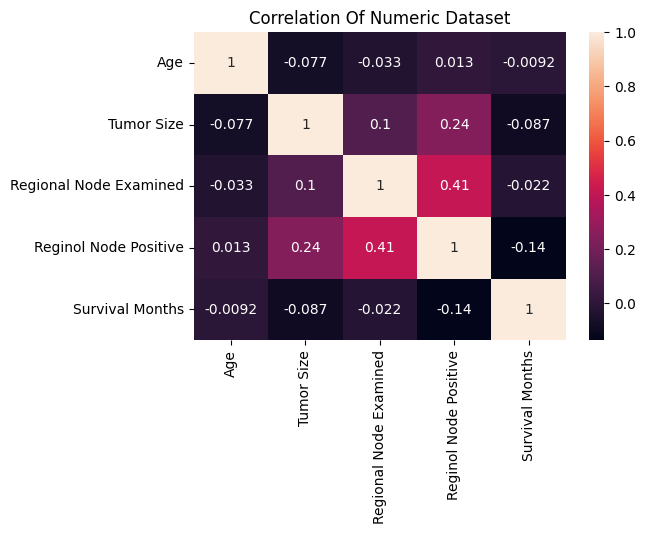

In [46]:
plt.figure(figsize=(6,4))  # Set the figure size for the heatmap
sns.heatmap(corr, annot=True,)
plt.title("Correlation Of Numeric Dataset")
plt.show()

#### **Checking Unique Values and Distribution of Categorical Columns**

The following code is used to analyze categorical variables in the dataset:

- `clean_df['Status'].unique()` → Shows all unique values present in the **Status** column
- `clean_df['Status'].value_counts()` → Displays the frequency of each category in **Status**
- `clean_df["Marital Status"].value_counts()` → Shows count of each category in **Marital Status**

This helps in understanding class distribution and identifying imbalanced categories in the dataset.

In [47]:
print(f"Unique In Patient Status: {clean_df['Status'].unique()}")
print(clean_df['Status'].value_counts())
print(clean_df["Marital Status"].value_counts())


Unique In Patient Status: ['Alive' 'Dead']
Status
Alive    3407
Dead      616
Name: count, dtype: int64
Marital Status
Married      2642
Single        615
Divorced      486
Widowed       235
Separated      45
Name: count, dtype: int64


#### **Marital Status vs Patient Status Analysis**

- `pd.crosstab()` shows relationship between **Marital Status** and **Status**
- `sns.countplot()` visualizes their distribution
- `hue="Status"` separates patient status categories
- Helps in understanding category-wise distribution and patterns

This is useful for quick EDA on categorical variables.

Status          Alive  Dead
Marital Status             
Divorced          396    90
Married          2284   358
Separated          30    15
Single            511   104
Widowed           186    49


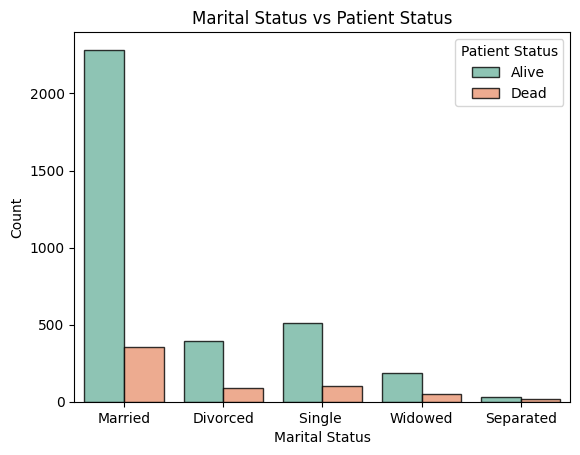

In [48]:
print(pd.crosstab(clean_df["Marital Status"], clean_df["Status"])) # Create a crosstab to show the relationship between "Marital Status" and "Status"
sns.countplot(
    x="Marital Status", hue="Status", data=clean_df, palette="Set2",  edgecolor="black", alpha=0.8
    )
plt.title("Marital Status vs Patient Status")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.legend(title="Patient Status")  
plt.show()

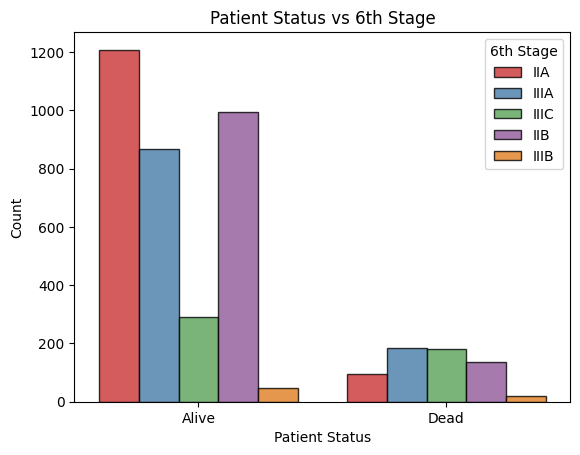

In [49]:
import seaborn as sns
sns.countplot(x=clean_df["Status"], palette="Set1", edgecolor="black", alpha=0.8, hue=clean_df["6th Stage"])
plt.title("Patient Status vs 6th Stage")
plt.xlabel("Patient Status")
plt.ylabel("Count")
plt.show()

In [50]:
df[(df["Status"] == "Alive") & (df["Age"] > 50)]

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
5,51,White,Single,T1,N1,IIA,Moderately differentiated,2,Regional,20,Positive,Positive,18,2,89,Alive
6,51,White,Married,T1,N1,IIA,Well differentiated,1,Regional,8,Positive,Positive,11,1,54,Alive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4018,64,White,Married,T1,N1,IIA,Moderately differentiated,2,Regional,10,Positive,Positive,11,1,70,Alive
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,49,Alive
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,69,Alive
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,69,Alive


#### **Outlier Detection using Boxplot**

This code is used to visualize outliers in numerical columns of the dataset:

- `select_dtypes()` → selects all numerical columns (int64, float64)
- Loop runs for each numerical column
- `plt.boxplot()` → creates boxplot for detecting outliers
- `showmeans=True` → shows mean value in the plot
- `vert=False` → horizontal boxplot for better readability

Boxplot helps in identifying:
- Outliers in data
- Data spread and distribution
- Median and quartile ranges

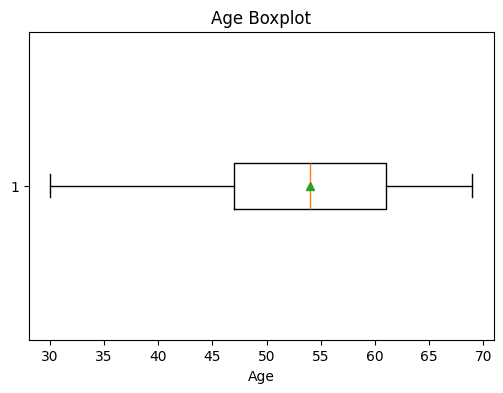

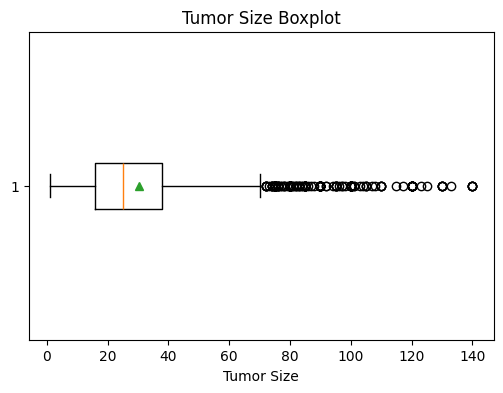

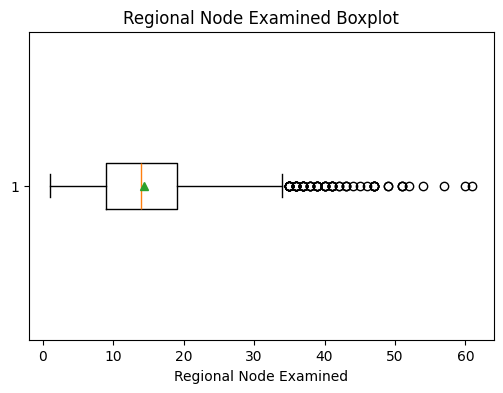

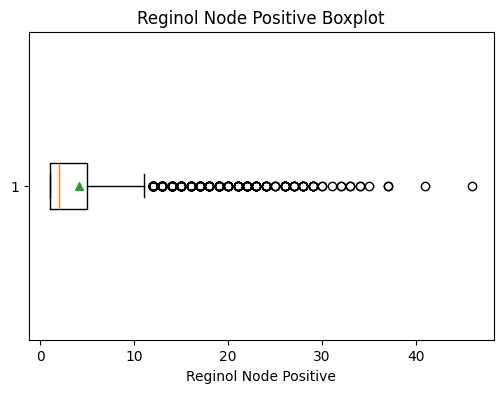

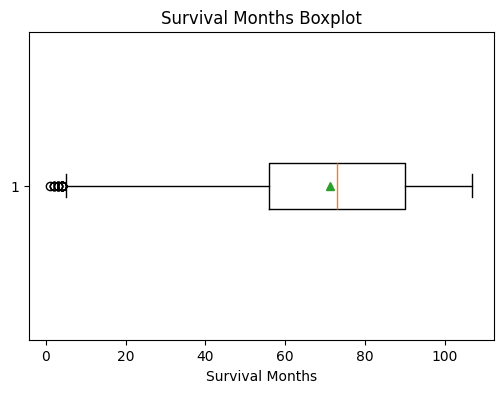

In [51]:
import matplotlib.pyplot as plt

# Numerical columns
num_cols = clean_df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(clean_df[col], vert=False, showmeans=True)
    plt.title(f"{col} Boxplot")
    plt.xlabel(col)
    plt.show()

#### **Handling Outliers using IQR Clipping**

This code is used to handle outliers in selected numerical columns:

- Selected columns: `Regional Node Examined`, `Reginol Node Positive`
- `Q1` and `Q3` → first and third quartiles
- `IQR (Interquartile Range)` → Q3 - Q1
- `lower_limit` and `upper_limit` → define acceptable data range
- `clip()` → replaces values outside range with boundary values

This method helps in reducing the impact of outliers without removing data.

In [52]:
cols_to_clip = [  
    "Regional Node Examined",
    "Reginol Node Positive"
]                                                                  # List of columns to apply clipping
for col in cols_to_clip:

    Q1 = clean_df[col].quantile(0.25)  # Calculate the first quartile (Q1)
    Q3 = clean_df[col].quantile(0.75)  # Calculate the third quartile (Q3)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR # Calculate the lower limit for outliers
    upper_limit = Q3 + 1.5 * IQR # Calculate the upper limit for outliers

    clean_df[col] = clean_df[col].clip(lower_limit, upper_limit) 

In [53]:
clean_df.describe()  # to check if the outliers have been handled properly

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4023.000000,4023.000000,4023.000000,4023.000000,4023.000000
mean,53.969923,30.477007,14.229431,3.568481,71.301765
std,8.963118,21.121253,7.674916,3.281311,22.923009
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,34.000000,11.000000,107.000000


Age                      -0.219932
Tumor Size                1.739386
Regional Node Examined    0.422325
Reginol Node Positive     1.264879
Survival Months          -0.590447
dtype: float64


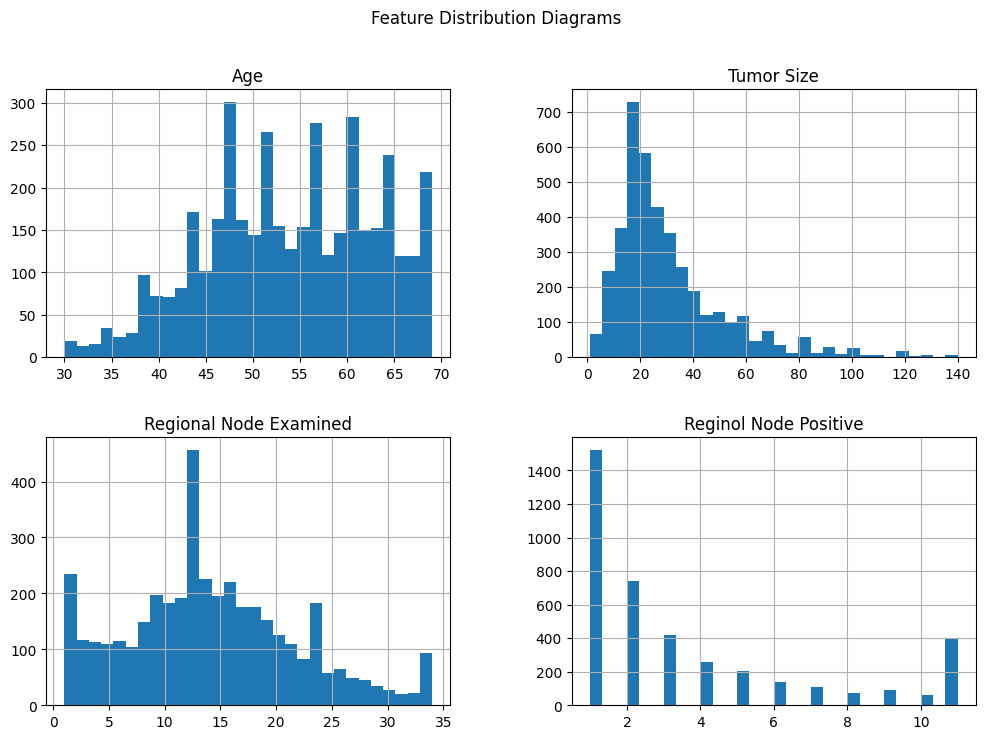

In [54]:
import matplotlib.pyplot as plt

# Numeric columns
numeric_df = clean_df.select_dtypes(include=['int64', 'float64'])

# Check skewness
print(numeric_df.skew())

# Features to visualize
features = [
    'Age',
    'Tumor Size',
    'Regional Node Examined',
    'Reginol Node Positive'
]

# Histograms
clean_df[features].hist(figsize=(12,8), bins=30)
plt.suptitle("Feature Distribution Diagrams")
plt.show()

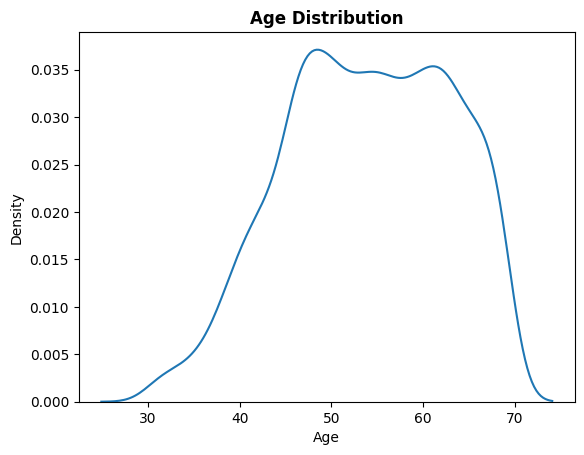

In [55]:
sns.kdeplot(clean_df["Age"])  # Plot the KDE for the "Age" column
plt.title("Age Distribution",fontweight="bold")
plt.show()

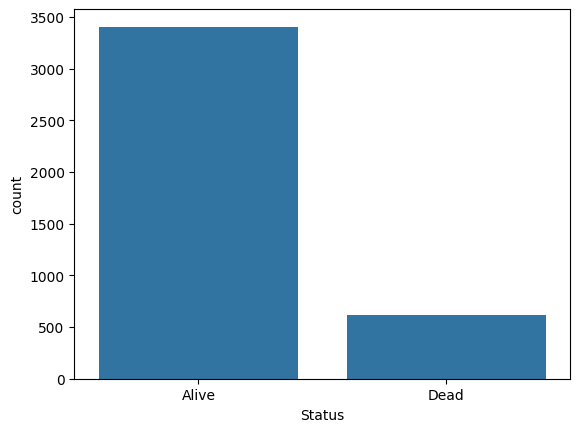

In [56]:
import seaborn as sns
sns.countplot(x=clean_df["Status"])
plt.show()

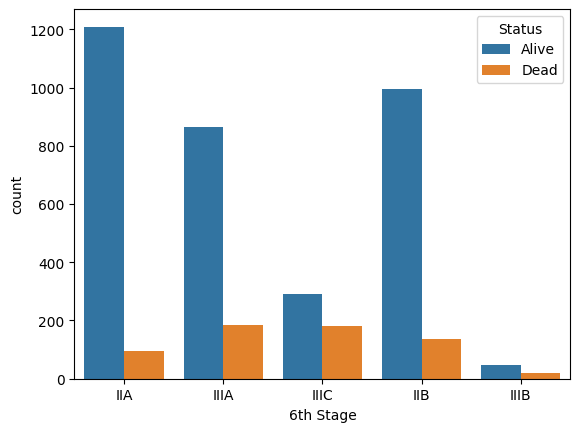

In [57]:
sns.countplot(x="6th Stage", hue="Status", data=df)  # Plot the count of "6th Stage" with hue based on "Status"

plt.show()

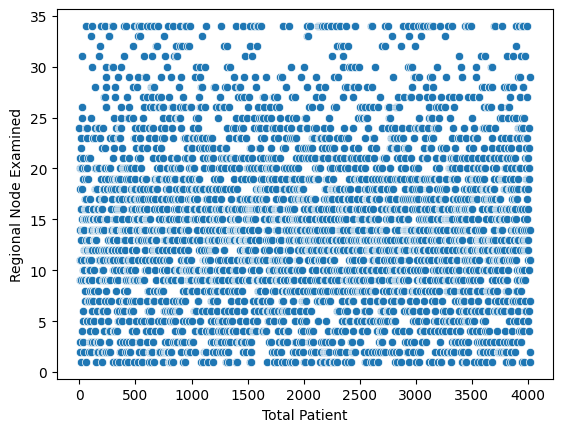

In [58]:
sns.scatterplot(clean_df["Regional Node Examined"]) # Plot a scatter plot for "Regional Node Examined"
plt.xlabel("Total Patient")
plt.ylabel("Regional Node Examined")
plt.show()

In [59]:
clean_df=clean_df.drop(["Survival Months", "A Stage", "differentiate", "Grade"], axis=1) # Drop the specified columns from the DataFrame


In [60]:
clean_df = clean_df.rename(columns={"T Stage ": "T Stage"}) # Rename the column "T Stage " to "T Stage" by removing the trailing space

In [61]:
clean_df.to_csv("data/clean_breast_cancer.csv", index=False)  # Save the cleaned DataFrame to a new CSV file without the index

In [62]:
numeric_df = clean_df.select_dtypes(include=['int64', 'float64'])

numeric_df.skew()

Age                      -0.219932
Tumor Size                1.739386
Regional Node Examined    0.422325
Reginol Node Positive     1.264879
dtype: float64

In [63]:
clean_df

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Status
0,68,White,Married,T1,N1,IIA,4,Positive,Positive,24,1,Alive
1,50,White,Married,T2,N2,IIIA,35,Positive,Positive,14,5,Alive
2,58,White,Divorced,T3,N3,IIIC,63,Positive,Positive,14,7,Alive
3,58,White,Married,T1,N1,IIA,18,Positive,Positive,2,1,Alive
4,47,White,Married,T2,N1,IIB,41,Positive,Positive,3,1,Alive
...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62,Other,Married,T1,N1,IIA,9,Positive,Positive,1,1,Alive
4020,56,White,Divorced,T2,N2,IIIA,46,Positive,Positive,14,8,Alive
4021,68,White,Married,T2,N1,IIB,22,Positive,Negative,11,3,Alive
4022,58,Black,Divorced,T2,N1,IIB,44,Positive,Positive,11,1,Alive


# **END OF ANALYSIS**